In [65]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict

In [66]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    sixes: int
    fours: int

    sr: float
    bpb: float
    boundary_percentage: float
    summary: str

In [67]:
def calculate_sr(state: BatsmanState) -> BatsmanState:

    sr = (state['runs']/state['balls'])*100
    state['sr'] = sr

    return {'sr': sr}

In [68]:
def calculate_bpb(state: BatsmanState) -> BatsmanState:

    bpb =state['balls']/(state['fours'] + state['sixes'])
    state['bpb'] = bpb

    return {'bpb': bpb}


In [69]:
def calculate_boundry_percentage(state: BatsmanState):

    boundary_percentage = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percentage': boundary_percentage}

In [70]:
def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percentage - {state['boundary_percentage']}
"""
    
    return {'summary': summary}

In [71]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundry_percentage', calculate_boundry_percentage)
graph.add_node('summary', summary)


graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundry_percentage')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundry_percentage', 'summary')

graph.add_edge('summary', END)

parallel_workflow = graph.compile()

In [72]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

parallel_workflow.invoke(intial_state)

{'runs': 100,
 'balls': 50,
 'sixes': 4,
 'fours': 6,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percentage': 48.0,
 'summary': '\nStrike Rate - 200.0 \n\nBalls per boundary - 5.0 \n\nBoundary percentage - 48.0\n'}

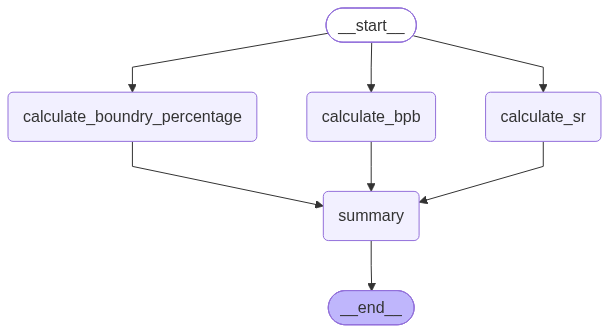

In [74]:
from IPython.display import Image, display
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))